# Experiment 002 — Pretrained TrOCR on IAM

Evaluate Microsoft's pretrained `microsoft/trocr-base-handwritten` model on a selected subset of the IAM Handwriting Database **without additional fine-tuning**.

Initial evaluation size: **N = 20**

Metrics:
- Character Error Rate (CER)
- Word Error Rate (WER)
- Exact Match


## 1. Setup

In [1]:
from pathlib import Path
import sys
import json

cwd = Path.cwd().resolve()

if (cwd / "src").exists() and (cwd / "data").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "src").exists() and (cwd.parent / "data").exists():
    PROJECT_ROOT = cwd.parent
else:
    raise FileNotFoundError(
        "Could not locate the project root. Open this notebook from the repository or notebooks/ directory."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("Python:", sys.executable)


Project root: /Users/aloyson/Documents/Thesis/ocr-thesis-handwritten-forms/trocr_beginner_project
Python: /Users/aloyson/Documents/Thesis/ocr-thesis-handwritten-forms/trocr_beginner_project/.venv/bin/python


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from tqdm.auto import tqdm
from src.metrics import calculate_cer, calculate_wer, exact_field_accuracy
print("PyTorch:", torch.__version__)


/Users/aloyson/Documents/Thesis/ocr-thesis-handwritten-forms/trocr_beginner_project/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch: 2.14.0


## 2. Load IAM Samples

In [3]:
CSV_PATH = PROJECT_ROOT / "data" / "iam" / "iam_sample.csv"

if not CSV_PATH.exists():
    raise FileNotFoundError(f"IAM sample CSV was not found: {CSV_PATH}. Run src/create_iam_sample.py first.")

df = pd.read_csv(CSV_PATH)
required_columns = {"image", "text"}
missing = required_columns - set(df.columns)
if missing:
    raise ValueError(f"CSV is missing required columns: {sorted(missing)}")

print("CSV:", CSV_PATH)
print("Samples available:", len(df))
df.head()


CSV: /Users/aloyson/Documents/Thesis/ocr-thesis-handwritten-forms/trocr_beginner_project/data/iam/iam_sample.csv
Samples available: 8816


,id,image,text
0,a01-003-00,/Users/aloyson/Documents/Thesis/ocr-thesis-han...,"Though they may gather some Left-wing support , a"
1,a01-003-01,/Users/aloyson/Documents/Thesis/ocr-thesis-han...,large majority of Labour M Ps are likely to
2,a01-003-02,/Users/aloyson/Documents/Thesis/ocr-thesis-han...,turn down the Foot-Griffiths resolution . Mr.
3,a01-003-03,/Users/aloyson/Documents/Thesis/ocr-thesis-han...,Foot's line will be that as Labour M Ps
4,a01-003-04,/Users/aloyson/Documents/Thesis/ocr-thesis-han...,opposed the Government Bill which brought


In [4]:
missing_images = [
    p for p in df["image"]
    if not Path(p).exists()
]

if missing_images:
    print(f"Warning: {len(missing_images)} image paths do not exist.")
    print("First missing path:", missing_images[0])
else:
    print(f"All {len(df)} image paths verified successfully.")


All 8816 image paths verified successfully.


## 3. Display Sample

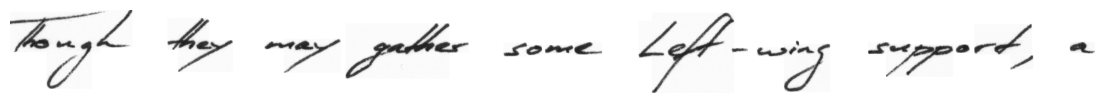

Sample ID: a01-003-00
Ground Truth:
Though they may gather some Left-wing support , a


In [5]:
sample = df.iloc[0]
image_path = Path(sample["image"])
image = Image.open(image_path).convert("RGB")
plt.figure(figsize=(14, 3))
plt.imshow(image)
plt.axis("off")
plt.show()
print("Sample ID:", sample.get("id", image_path.stem))
print("Ground Truth:")
print(sample["text"])


## 4. Load Pretrained TrOCR

In [6]:
MODEL_NAME = "microsoft/trocr-base-handwritten"
processor = TrOCRProcessor.from_pretrained(MODEL_NAME)
model = VisionEncoderDecoderModel.from_pretrained(MODEL_NAME)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

model.to(device)
model.eval()
print("Model:", MODEL_NAME)
print("Device:", device)


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-base-handwritten and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model: microsoft/trocr-base-handwritten
Device: mps


## 5. Run Inference

In [7]:
pixel_values = processor(images=image, return_tensors="pt").pixel_values.to(device)
with torch.no_grad():
    generated_ids = model.generate(pixel_values)
prediction = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
print("Prediction:")
print(prediction)


Prediction:
though they may gather some Left-wing support , a


## 6. Ground Truth vs Prediction

In [8]:
reference = str(sample["text"])
print("Ground Truth:")
print(reference)
print("\nPrediction:")
print(prediction)


Ground Truth:
Though they may gather some Left-wing support , a

Prediction:
though they may gather some Left-wing support , a


## 7. Calculate CER

In [9]:
sample_cer = calculate_cer(reference, prediction)
print(f"CER: {sample_cer:.4f}")


CER: 0.0204


## 8. Calculate WER

In [10]:
sample_wer = calculate_wer(reference, prediction)
sample_exact = exact_field_accuracy(reference, prediction)
print(f"WER:   {sample_wer:.4f}")
print(f"Exact: {sample_exact}")


WER:   0.1111
Exact: 0


## 9. Run Over N Samples

In [11]:
N = min(100, len(df))
print(f"Evaluating {N} samples...")


Evaluating 100 samples...


In [12]:
results = []

for _, row in tqdm(df.head(N).iterrows(), total=N):
    image_path = Path(row["image"])
    reference = str(row["text"])
    try:
        image = Image.open(image_path).convert("RGB")
        pixel_values = processor(images=image, return_tensors="pt").pixel_values.to(device)
        with torch.no_grad():
            generated_ids = model.generate(pixel_values)
        prediction = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
        results.append({
            "sample": row.get("id", image_path.stem),
            "image": str(image_path),
            "ground_truth": reference,
            "prediction": prediction,
            "cer": calculate_cer(reference, prediction),
            "wer": calculate_wer(reference, prediction),
            "exact": exact_field_accuracy(reference, prediction),
        })
    except Exception as exc:
        print(f"Skipping {image_path.name}: {exc}")

results_df = pd.DataFrame(results)
results_df


100%|██████████| 100/100 [00:31<00:00,  3.15it/s]


,sample,image,ground_truth,prediction,cer,wer,exact
0,a01-003-00,/Users/aloyson/Documents/Thesis/ocr-thesis-han...,"Though they may gather some Left-wing support , a","though they may gather some Left-wing support , a",0.020408,0.111111,0
1,a01-003-01,/Users/aloyson/Documents/Thesis/ocr-thesis-han...,large majority of Labour M Ps are likely to,large majority of Labour MPs are likely to,0.023256,0.222222,0
2,a01-003-02,/Users/aloyson/Documents/Thesis/ocr-thesis-han...,turn down the Foot-Griffiths resolution . Mr.,turn down the Foot-Griffiths resolution . Mr.,0.000000,0.000000,1
3,a01-003-03,/Users/aloyson/Documents/Thesis/ocr-thesis-han...,Foot's line will be that as Labour M Ps,Foot's line will be that as Labour MPs,0.025641,0.222222,0
4,a01-003-04,/Users/aloyson/Documents/Thesis/ocr-thesis-han...,opposed the Government Bill which brought,opposed the Government Bill which brought,0.000000,0.000000,1
...,...,...,...,...,...,...,...
95,a01-058-03,/Users/aloyson/Documents/Thesis/ocr-thesis-han...,He said bluntly in Washington yester-,He said bluntly in Washington yester-,0.000000,0.000000,1
96,a01-058-04,/Users/aloyson/Documents/Thesis/ocr-thesis-han...,day that the offer - 357million - was,day that the offer - 357million - was,0.000000,0.000000,1
97,a01-058-07,/Users/aloyson/Documents/Thesis/ocr-thesis-han...,Germany to pay more . He did not,Germany to pay more . He did not,0.000000,0.000000,1
98,a01-058-08,/Users/aloyson/Documents/Thesis/ocr-thesis-han...,mention personal talks with Dr.,meention personal talks with Dr.,0.032258,0.200000,0


## 10. Aggregate Results

In [13]:
if results_df.empty:
    raise RuntimeError("No samples were evaluated successfully.")

summary = {
    "model": MODEL_NAME,
    "samples_evaluated": int(len(results_df)),
    "average_cer": float(results_df["cer"].mean()),
    "average_wer": float(results_df["wer"].mean()),
    "exact_matches": int(results_df["exact"].sum()),
    "exact_match_rate": float(results_df["exact"].mean()),
}

print(f"Samples evaluated : {summary['samples_evaluated']}")
print(f"Average CER       : {summary['average_cer']:.4f}")
print(f"Average WER       : {summary['average_wer']:.4f}")
print(f"Exact matches     : {summary['exact_matches']}")
print(f"Exact match rate  : {summary['exact_match_rate']:.2%}")


Samples evaluated : 100
Average CER       : 0.0115
Average WER       : 0.0368
Exact matches     : 81
Exact match rate  : 81.00%


## 11. Best Predictions

In [14]:
best_predictions = results_df.sort_values(["cer", "wer"], ascending=[True, True]).head(5)
best_predictions[["sample", "ground_truth", "prediction", "cer", "wer", "exact"]]


,sample,ground_truth,prediction,cer,wer,exact
2,a01-003-02,turn down the Foot-Griffiths resolution . Mr.,turn down the Foot-Griffiths resolution . Mr.,0.0,0.0,1
4,a01-003-04,opposed the Government Bill which brought,opposed the Government Bill which brought,0.0,0.0,1
5,a01-003-05,"life peers into existence , they should not","life peers into existence , they should not",0.0,0.0,1
6,a01-003-06,now put forward nominees . He believes,now put forward nominees . He believes,0.0,0.0,1
7,a01-003-07,that the House of Lords should be abolished,that the House of Lords should be abolished,0.0,0.0,1


## 12. Worst Predictions

In [15]:
worst_predictions = results_df.sort_values(["cer", "wer"], ascending=[False, False]).head(5)
worst_predictions[["sample", "ground_truth", "prediction", "cer", "wer", "exact"]]


,sample,ground_truth,prediction,cer,wer,exact
9,a01-003-10,institution .,institutionalism .,0.384615,0.500000,0
68,a01-038-12,talks .,"talks ,",0.142857,0.500000,0
83,a01-049-06,of Virginia - met today in closed session,of Virginia - need today in closed sessions,0.097561,0.250000,0
84,a01-049-08,Robertson later disclosed he had sent a letter,Robertson later disclosed the fact sent a letter,0.086957,0.250000,0
71,a01-043-02,defended the appointment of a Negro as,defenched the appointment of a Negro as,0.052632,0.142857,0


## Save Experiment Outputs

In [16]:
# Keep each EXP002 run separate
RUN_NAME = f"n{N}"

OUTPUT_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "exp002"
    / RUN_NAME
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

results_df.to_csv(
    OUTPUT_DIR / "predictions.csv",
    index=False
)

best_predictions.to_csv(
    OUTPUT_DIR / "best_predictions.csv",
    index=False
)

worst_predictions.to_csv(
    OUTPUT_DIR / "worst_predictions.csv",
    index=False
)

with open(
    OUTPUT_DIR / "summary.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(summary, f, indent=2)

print("Results saved to:")
print(OUTPUT_DIR)

Results saved to:
/Users/aloyson/Documents/Thesis/ocr-thesis-handwritten-forms/trocr_beginner_project/outputs/exp002/n100


## 13. Observations

Complete this section after running the experiment.

### Quantitative Results
- Samples evaluated:
- Average CER:
- Average WER:
- Exact matches:
- Exact match rate:

### Good Predictions
- What kinds of handwriting were recognized accurately?
- Were shorter or cleaner lines easier?

### Poor Predictions
- What characteristics appear in the worst predictions?
- Are errors caused by difficult handwriting, punctuation, spacing, long lines, or image quality?

### Error Categories
- Character substitutions
- Character insertions
- Character deletions
- Word substitutions
- Missing words
- Spacing/punctuation errors

### Limitations
- Initial experiment uses only 20 IAM samples.
- The model is evaluated without additional IAM fine-tuning.
- This experiment evaluates text recognition, not structured-form field detection.

### Next Step
1. Evaluate 50 samples.
2. Evaluate 100 samples.
3. Prepare official IAM train/validation/test splits.
4. Use the official test split for a reproducible baseline.
